In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from opacus import PrivacyEngine
import gc
import numpy as np

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Grayscale()
])

train_dataset  = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader  = DataLoader(dataset=train_dataset, batch_size=1000, shuffle=False)

test_dataset  = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = Model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

privacy_engine = PrivacyEngine()

gc.collect()

/opt/anaconda3/lib/python3.12/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


20

In [ ]:
epochs = 15
train_losses_2 = []
train_accuracies_2 = []
test_losses_2 = []
test_accuracies_2 = []
model.train()
target_delta = 1e-5
model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    epochs=epochs,
    target_epsilon=5,
    target_delta=target_delta,
    max_grad_norm=0.1,
)
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Epoch [{epoch + 1}/{epochs}]')
    print("Training loss", (running_loss / total))
    train_losses_2.append(running_loss / total)
    print("Training accuracy", (correct *100/ total),'%')
    train_accuracies_2.append(correct * 100 / total)
    gc.collect()

    epsilon = privacy_engine.get_epsilon(delta=target_delta)
    print(f"Privacy Budget (epsilon, delta): ({epsilon:.2f}, {target_delta})")

    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses_2.append(running_loss_eval / total)
    print("Testing accuracy", (correct*100 / total),'%')
    test_accuracies_2.append(correct * 100 / total)

    gc.collect()
    model.eval()
    correct = 0
    total = 0
    eval_loss = 0.0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            eval_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

print(f"Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

/opt/anaconda3/lib/python3.12/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/15]
Training loss 2.3049553758022125
Training accuracy 10.065362082021442 %
Privacy Budget (epsilon, delta): (1.92, 1e-05)
Testing loss 2.305041551589966
Testing accuracy 10.0 %
Epoch [2/15]
Training loss 2.3050361767487413
Training accuracy 9.830522120687572 %
Privacy Budget (epsilon, delta): (2.31, 1e-05)
Testing loss 2.304666209220886
Testing accuracy 10.0 %
Epoch [3/15]
Training loss 2.304406577467717
Training accuracy 9.91556570974471 %
Privacy Budget (epsilon, delta): (2.62, 1e-05)
Testing loss 2.3043383359909058
Testing accuracy 10.0 %
Epoch [4/15]
Training loss 2.3041801692978603
Training accuracy 10.044816253361219 %
Privacy Budget (epsilon, delta): (2.89, 1e-05)
Testing loss 2.304027223587036
Testing accuracy 10.0 %
Epoch [5/15]
Training loss 2.3037271216589326
Training accuracy 10.099962090225263 %
Privacy Budget (epsilon, delta): (3.13, 1e-05)
Testing loss 2.3037315130233766
Testing accuracy 10.0 %


/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/rubenhayrapetyan/Library/Python/3.9/lib/python/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


Epoch [1/50]
Training loss 2.275849658344356
Training accuracy 14.201420944888211 %
Testing loss 2.1978020429611207
Testing accuracy 22.02 %
Epoch [2/50]
Training loss 2.176604504358151
Training accuracy 20.162754053892336 %
Testing loss 2.1103391647338867
Testing accuracy 25.58 %
Epoch [3/50]
Training loss 2.127575545910604
Training accuracy 23.054108216432866 %
Testing loss 2.0382168292999268
Testing accuracy 28.31 %
Epoch [4/50]
Training loss 2.077614067137465
Training accuracy 25.284199129859456 %
Testing loss 1.9761457204818726
Testing accuracy 30.0 %
Epoch [5/50]
Training loss 2.0481411918607746
Training accuracy 26.58941058941059 %
Testing loss 1.9501839995384216
Testing accuracy 31.01 %
Epoch [6/50]
Training loss 2.0156350288010225
Training accuracy 27.816894345148544 %
Testing loss 1.9035105466842652
Testing accuracy 32.31 %
Epoch [7/50]
Training loss 1.9971669465871045
Training accuracy 28.707046129913643 %
Testing loss 1.8578008174896241
Testing accuracy 34.16 %
Epoch [8/50]

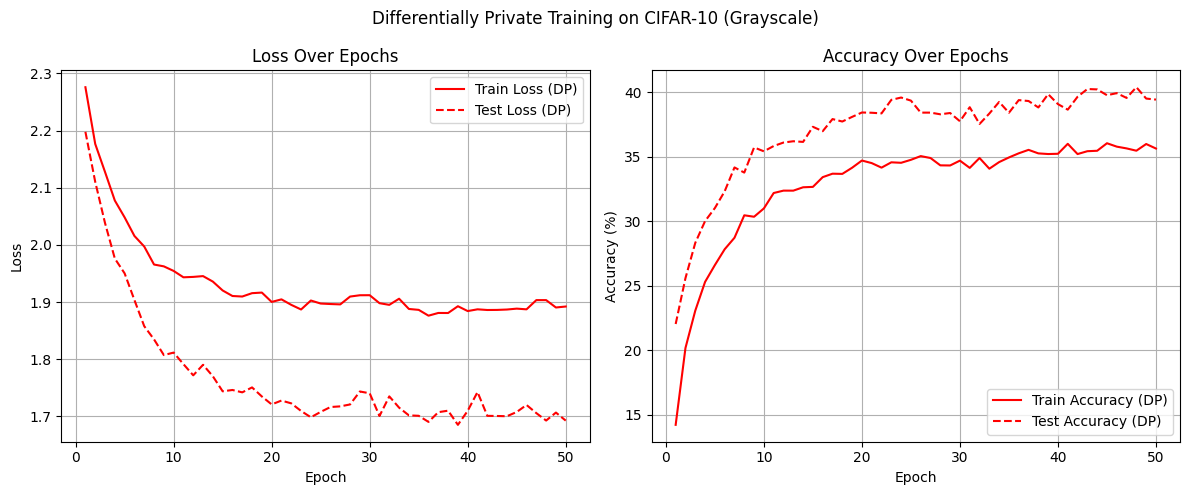


Privacy Budget Used:
Epsilon: 2.9951
Delta: 1e-5

CIFAR-10 Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Note: Images are converted to grayscale (1 channel) and resized to 28x28


In [1]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import gc
from opacus import PrivacyEngine
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Grayscale()  # Converting to grayscale (1 channel)
])

train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# Model definition - Fixed to work with 1 channel (grayscale) input
class CIFAR10Net(nn.Module):
    def __init__(self):
        super(CIFAR10Net, self).__init__()
        # First conv layer: 1 input channel (grayscale) to match the preprocessing
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate the flattened size: 28x28 -> 14x14 -> 7x7 -> 3x3 (with padding adjustments)
        # After 3 pooling operations on 28x28: 28->14->7->3, so 3*3*128 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 10)  # 10 classes for CIFAR-10

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = x.view(-1, 128 * 3 * 3)  # Flatten the tensor
        x = self.relu4(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model, criterion, and optimizer
model = CIFAR10Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# Initialize privacy engine
privacy_engine = PrivacyEngine()

# Make the model private
model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    epochs=50,
    target_epsilon=3,
    target_delta=1e-5,
    max_grad_norm=1.0,
)

# Training loop
epochs = 50
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    print(f'Epoch [{epoch + 1}/{epochs}]')
    print("Training loss", (running_loss / total))
    train_losses.append(running_loss / total)
    print("Training accuracy", (correct * 100 / total), '%')
    train_accuracies.append(correct * 100 / total)
    gc.collect()

    # Evaluation
    model.eval()
    running_loss_eval = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss_eval += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print("Testing loss", (running_loss_eval / total))
    test_losses.append(running_loss_eval / total)
    print("Testing accuracy", (correct * 100 / total), '%')
    test_accuracies.append(correct * 100 / total)
    gc.collect()

# Final evaluation
model.eval()
correct = 0
total = 0
eval_loss = 0.0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        eval_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

print(f"Final Test Loss: {eval_loss / total:.4f}, Accuracy: {100 * correct / total:.2f}%")

# Plotting
plt.figure(figsize=(12, 5))
plt.suptitle('Differentially Private Training on CIFAR-10 (Grayscale)')

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, 'r-', label='Train Loss (DP)')
plt.plot(range(1, epochs + 1), test_losses, 'r--', label='Test Loss (DP)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, 'r-', label='Train Accuracy (DP)')
plt.plot(range(1, epochs + 1), test_accuracies, 'r--', label='Test Accuracy (DP)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print privacy budget spent
print(f"\nPrivacy Budget Used:")
print(f"Epsilon: {privacy_engine.get_epsilon(delta=1e-5):.4f}")
print(f"Delta: 1e-5")

# Print CIFAR-10 class names
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(f"\nCIFAR-10 Classes: {classes}")
print("Note: Images are converted to grayscale (1 channel) and resized to 28x28")
